In [31]:
from Tools.analysis_tools import *

In [32]:
# Percorso della cartella contenente i file CSV degli encoder
encoder_folder = "Encoder Analysis Data"

# Carica i dati
encoder_data = load_encoder_analysis_data(encoder_folder)


# Order the dataset
config_file = 'encoderDatabase.json'
enriched_data = enrich_analysis_with_config(encoder_data, config_file)

# Visualizza i dati caricati
print(encoder_data.head())


Caricando dati da: Encoder Analysis Data/30-20,15.csv
Caricando dati da: Encoder Analysis Data/Model15.csv
Caricando dati da: Encoder Analysis Data/30-20.csv
Caricando dati da: Encoder Analysis Data/30,20-Noise15,0.csv
Caricando dati da: Encoder Analysis Data/30-20_Noise10,0.csv
Caricando dati da: Encoder Analysis Data/Model_1.csv
Caricando dati da: Encoder Analysis Data/30-20,5.csv
Caricando dati da: Encoder Analysis Data/30-20,10.csv
Caricando dati da: Encoder Analysis Data/30,20-Noise21,0.csv
Caricando dati da: Encoder Analysis Data/30-20_Noise5,0.csv
Totale modelli caricati: 10
        Model Name  Latent Dim  Z2 R2 Mean  Z2 R2 Std  Z2 MSE Mean  \
0         30-20,15           5    0.793648   0.217596     0.013547   
1          Model15           5    0.793069   0.204684     0.013260   
2            30-20           5    0.985236   0.025621     0.001146   
3  30,20-Noise15,0           5    0.933932   0.082916     0.003764   
4  30-20_Noise10,0           5    0.967837   0.033401     0.0

In [33]:
# Lista dei filtri

'''
filter_type: equals o range
filter_value: valore del parametro (numero o range)
'''

filters = [
    {"param_name": "tau", "filter_type": "equals", "filter_value": 15},
    {"param_name": "alpha", "filter_type": "equals", "filter_value": 0}
]

filtered_data = filter_by_config_params(enriched_data, filters,True)
#print(filtered_data)

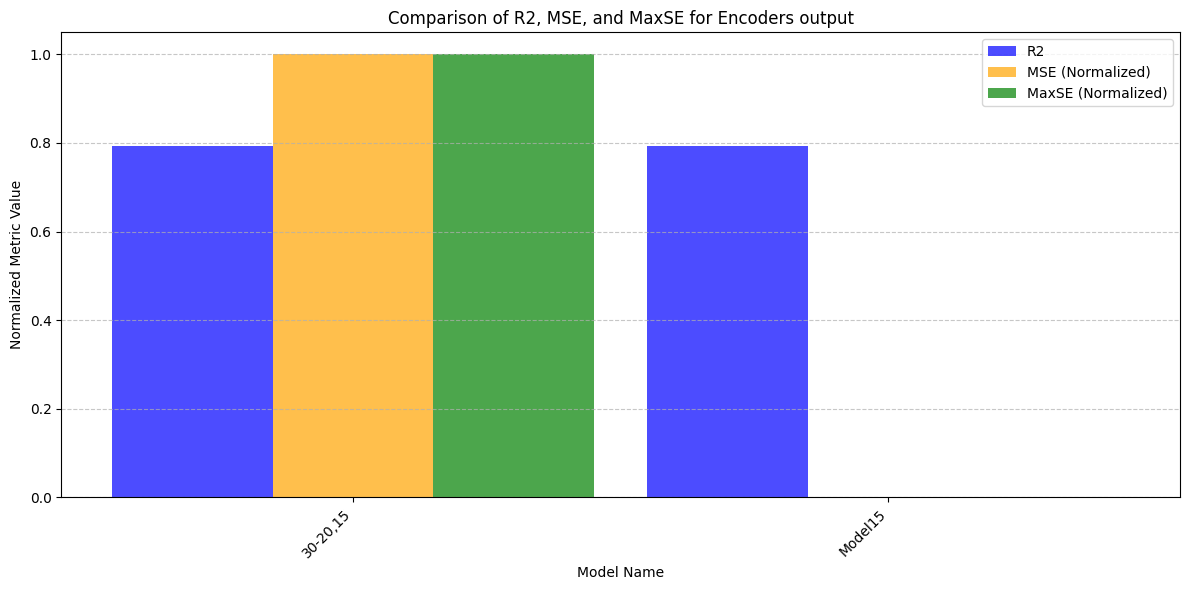

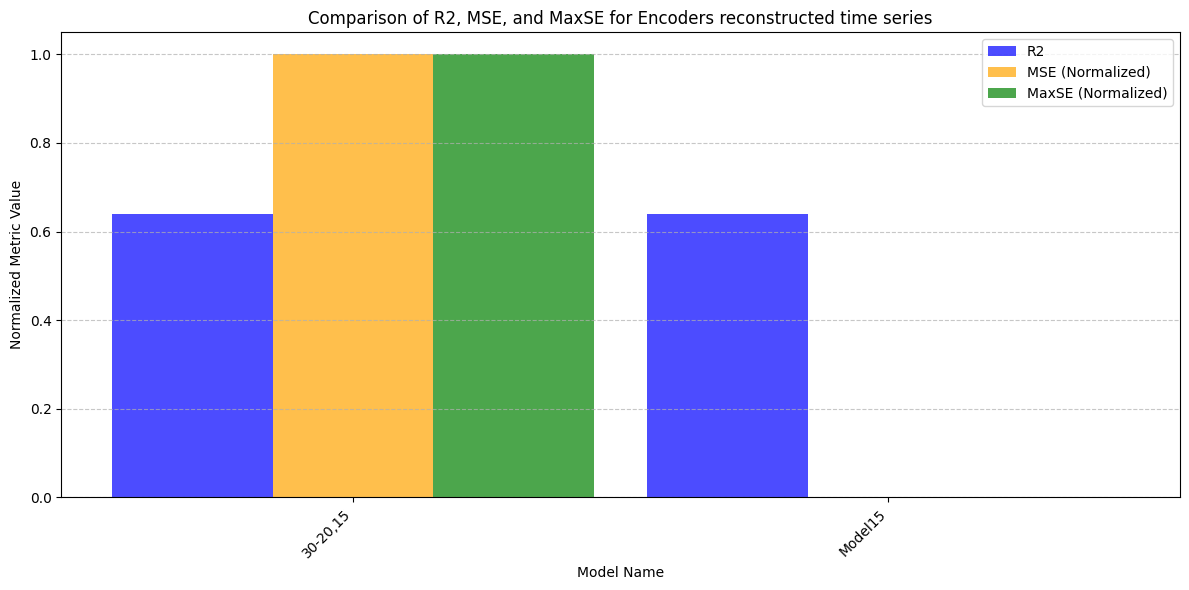

In [34]:
plot_z_metrics(
    data=filtered_data, 
    r2_col="Z2 R2 Mean", 
    mse_col="Z2 MSE Mean", 
    maxse_col="Z2 MaxSE Mean", 
    title="Comparison of R2, MSE, and MaxSE for Encoders output"
)
plot_z_metrics(
    data=filtered_data, 
    r2_col="PCA R2 Time Signal Z2", 
    mse_col="Z2 MSE Mean", 
    maxse_col="Z2 MaxSE Mean", 
    title="Comparison of R2, MSE, and MaxSE for Encoders reconstructed time series"
)

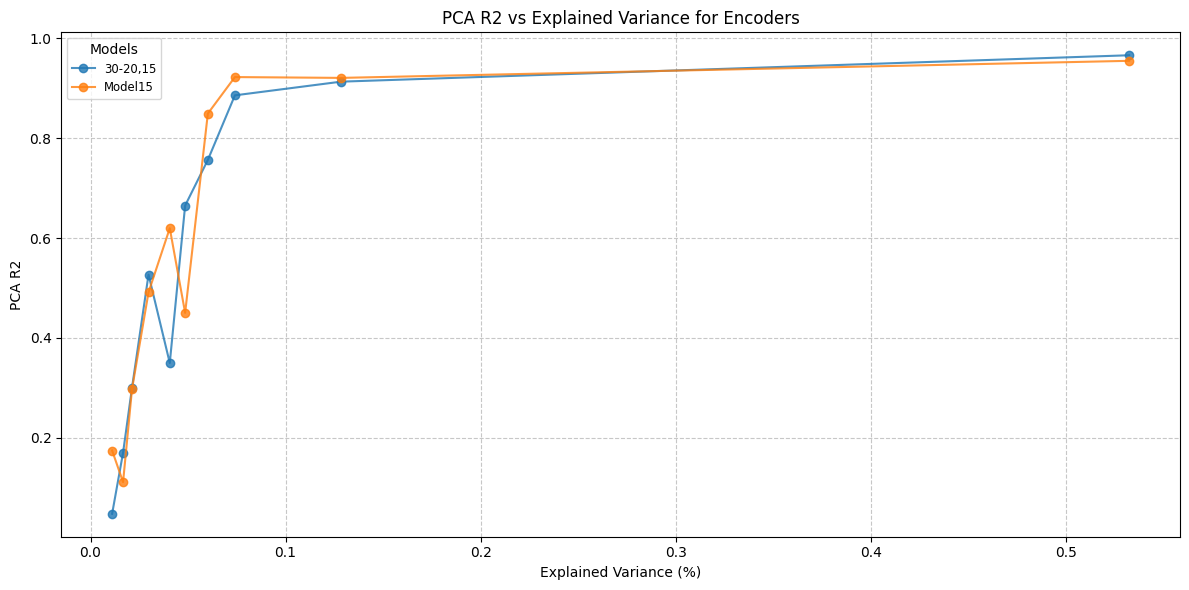

In [35]:
plot_pca_r2_and_variance(
    data=filtered_data,
    r2_col="PCA R2 Z2 PC",
    variance_col="Varianzce Explained Z2",
    title="PCA R2 vs Explained Variance for Encoders"
)


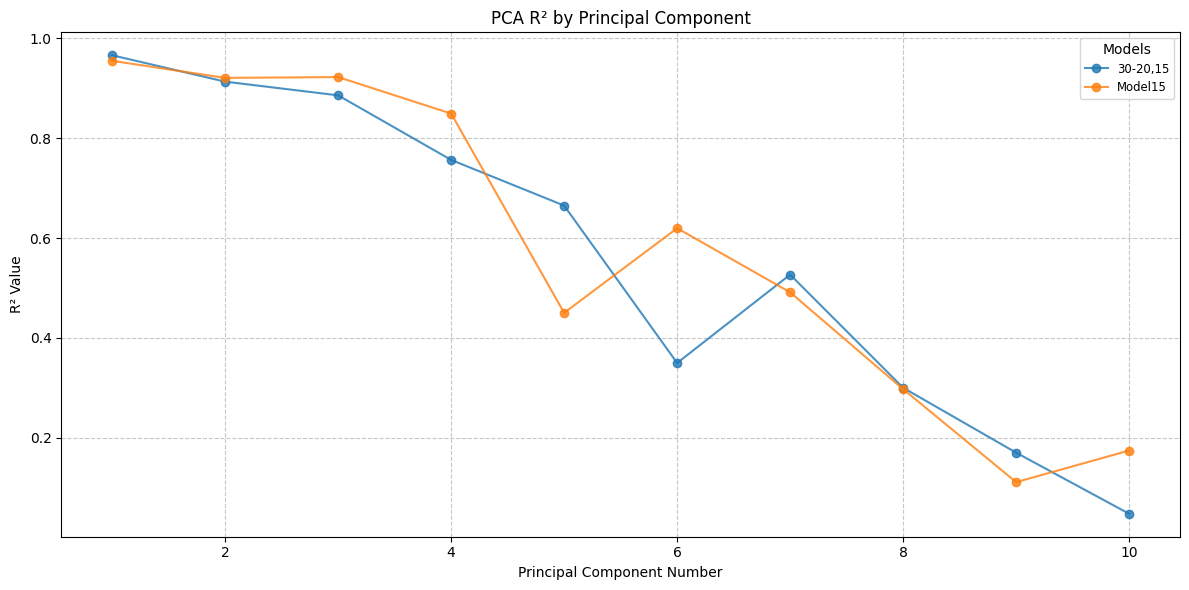

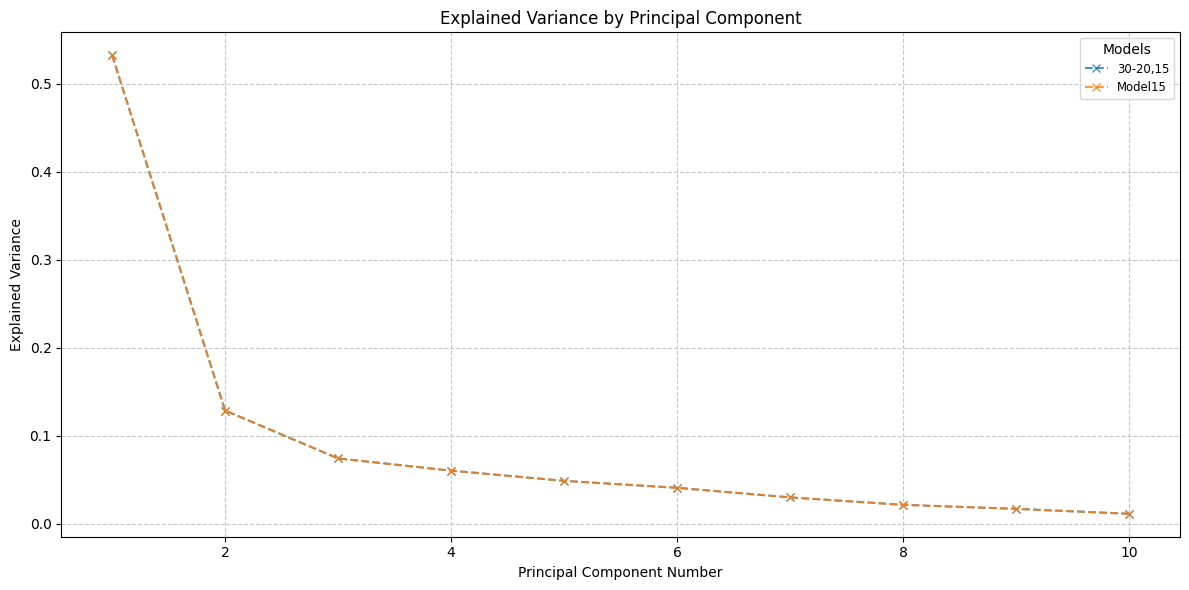

In [36]:
plot_r2_and_variance_separate(
    data=filtered_data, 
    r2_col="PCA R2 Z2 PC", 
    variance_col="Varianzce Explained Z2"
)

#Nota: La varianza spiegata è quasi sempre uguale (asse x)
